In [2]:
# k =2 or 3: these choices can be beneficial when computational resources are limited 
# or when a quicker evaluation is needed . They reduce the number of training cycles,
#     thus saving time and computational power while still providing a reasonable estimate
#     of model performance.

# k =5 or 10: choosing k=5 or k=10 are popular choices because they provide a good 
# popular choices because they provide a good balance b/w computational efficiency and model performance 
# estimation.

# k=20: using a large value of k can provide a more detailed performance evaluation.
# However, it increases the computational burden and might result in higher variance if the subsets
# are too small.

In [3]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

In [4]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [5]:
import pandas as pd 
x= pd.DataFrame(data.data,columns = data.feature_names)
y = data.target

In [6]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [7]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [8]:
from sklearn.model_selection import KFold

In [11]:
kf = KFold(n_splits=5,shuffle=True,random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [13]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=kf,scoring='r2')
scores

array([0.57578771, 0.61374822, 0.60856043, 0.62126494, 0.5875292 ])

In [14]:
import numpy as np
average_r2 = np.mean(scores)

print(f"R2 score for each fold:{[round(score,4)for score in scores]}")
print(f"Average r2 across{kf} folds:{average_r2:.2f}")

R2 score for each fold:[np.float64(0.5758), np.float64(0.6137), np.float64(0.6086), np.float64(0.6213), np.float64(0.5875)]
Average r2 acrossKFold(n_splits=5, random_state=42, shuffle=True) folds:0.60


In [ ]:
# Advantages of K-Fold Cross-Validation
# Maximized Data use : by rotating the test set and using every data point,
# k-fold cross-validation ensures comprehensive use of available data, crucial 
# for learning from small datasets

# reduced bias : Since every data points gets to be in a test set once,
# it reduces the bias associated with random data shuffling.

In [17]:
import pandas as pd
data ={
    "Class":['Pass']*50+['Fail']*50
}

df = pd.DataFrame(data)
print(df['Class'].value_counts())

Class
Pass    50
Fail    50
Name: count, dtype: int64


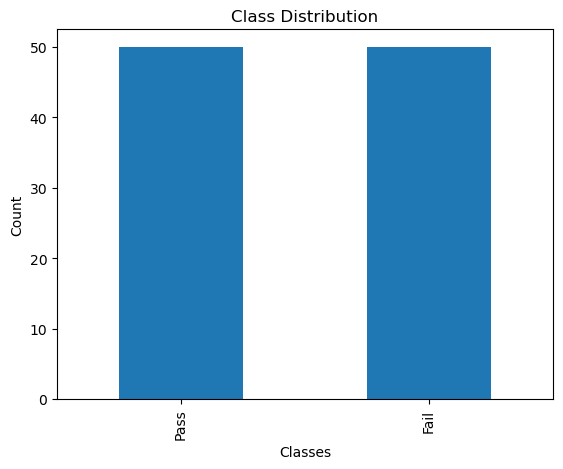

In [18]:
import matplotlib.pyplot as plt
df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()

In [19]:
data ={'Class':['Normal']*95+['Fraud']*5}
df = pd.DataFrame(data)
print(df['Class'].value_counts())

Class
Normal    95
Fraud      5
Name: count, dtype: int64


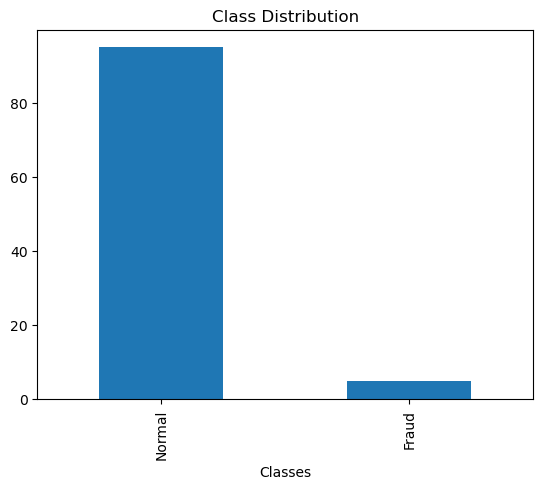

In [20]:
import matplotlib.pyplot as plt
df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.show()

In [21]:
from sklearn.metrics import accuracy_score
y_true = ['Normal']*95+['Fraud']*5
y_pred = ['Normal']*100
print('Accuracy:',accuracy_score(y_true,y_pred))

Accuracy: 0.95


In [22]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true,y_pred)
print(cm)

[[ 0  5]
 [ 0 95]]
